In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
# Define the function
def f(x, y):
    return -1000*y + 3000 - 2000*math.exp(-x)

# Analytical solution
def analytical_sol(x):
    return 3 - 0.998*np.exp(-1000*x) - 2.002*np.exp(-x)

# Euler Forward method
def euler_forward(h, x_start=0, x_end=30):
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    y_values[0] = 0  # initial condition

    for i in range(num_steps):
        y_values[i+1] = y_values[i] + h * f(x_values[i], y_values[i])

    return x_values, y_values

Made new working h values so I can see the graph.

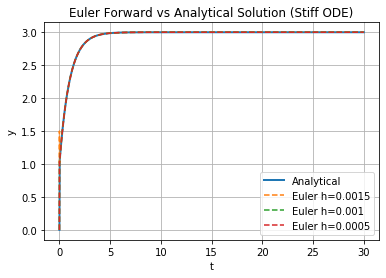

In [4]:
# Step sizes
# h_values = [0.1, 0.01, 0.001, 0.00001, 0.0000001] #Does not run with this
h_values = [0.0015, 0.001, 0.0005]

# Plot analytical solution
x_exact = np.linspace(0, 30, 1000)
y_exact = analytical_sol(x_exact)

plt.figure()

plt.plot(x_exact, y_exact, label="Analytical", linewidth=2)

# Plot Euler results
for h in h_values:
    x_euler, y_euler = euler_forward(h)
    plt.plot(x_euler, y_euler, '--', label=f"Euler h={h}")

plt.xlabel("t")
plt.ylabel("y")
plt.title("Euler Forward vs Analytical Solution (Stiff ODE)")
plt.legend()
plt.grid()

plt.show()